Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE
BITPIX
NAXIS
NAXIS1
NAXIS2
16
(530, 530)
2
>i2


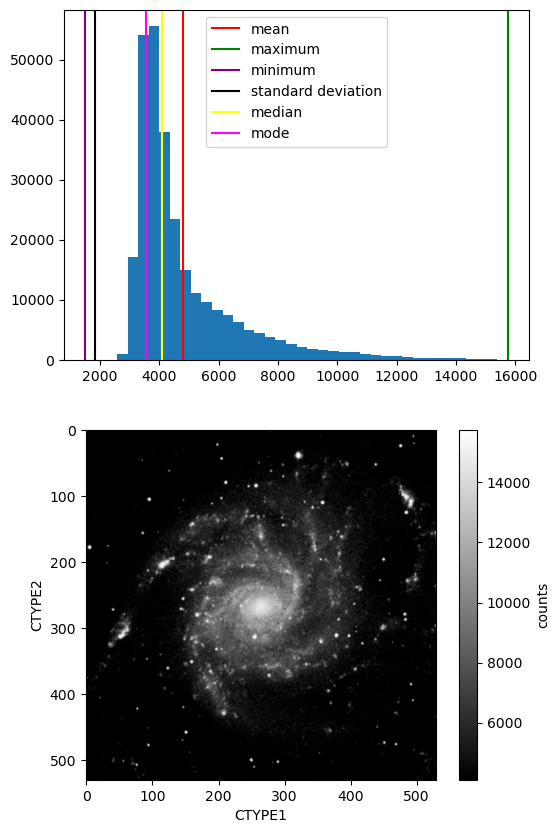

In [143]:
from astropy.io import fits
from statistics import mode
import matplotlib.pyplot as plt
import numpy as np

fits.info("m101.fits") # There are 2 HDU's, the data is in the PrimaryHDU with index 0, ??
file = fits.open("m101.fits")

dat = file[0].data
header = file[0].header

n = 0
for i in header:
    if n < 5:
        print(i)
        n += 1
        
print(header["BITPIX"]) #16

print(dat.shape) # 530 x 530, same as info yes
print(header["NAXIS"]) # naxis just prints "2"
print(dat.dtype) # >i2, BITPIX is int

oned = dat.flatten()

mean, maximum, minimum, SD, median, mode = np.mean(oned), np.max(oned), np.min(oned), np.std(oned), np.median(oned), mode(oned)

fig, (ax, ax2) = plt.subplots(2,1, figsize=(6,10))
ax.hist(oned, bins=40)
ax.axvline(mean, color="red", label="mean")
ax.axvline(maximum, color="green", label="maximum")
ax.axvline(minimum, color="purple", label="minimum")
ax.axvline(SD, color="black", label="standard deviation")
ax.axvline(median, color="yellow", label="median")
ax.axvline(mode, color="magenta", label="mode")
ax.legend()

pro = np.asarray(dat, dtype=float)
pro_median = np.median(pro)
im = ax2.imshow(pro, cmap="grey", vmin=pro_median)
fig.colorbar(im, ax = ax2, label="counts")
ax2.set_xlabel("CTYPE1")
ax2.set_ylabel("CTYPE2")

header["BUNIT"] = "Counts"

hdulistout = fits.PrimaryHDU(pro)
hdulistout.header = header
hdulistout.writeto('float_m101.fits', overwrite=True, output_verify='ignore')

In [10]:
from astropy.io import fits
from statistics import mode
import matplotlib.pyplot as plt
import numpy as np

data = fits.getdata("m101.fits")
block = data[300:330,300:330]
RMS = 0
RMS = np.sqrt(np.mean(block.astype(float)**2))
block_mean, block_std = np.mean(block), np.std(block)

print(RMS, block_std, block_mean)

6684.728955113538 672.6628746167387 6650.7988888888885


In [43]:
from astropy.io import fits
from statistics import mode
import matplotlib.pyplot as plt
import numpy as np

noisemap1 = fits.getdata("noisemap0.fits")
noisemap2 = fits.getdata("noisemap1.fits")
noisemap3 = fits.getdata("noisemap2.fits")

std1 = np.std(noisemap1)
std2 = np.std(noisemap2)
std3 = np.std(noisemap3)

stack = np.stack((noisemap1, noisemap2, noisemap3), axis=0)

mean_stack = np.mean(stack, axis=0)

std_stack = np.std(mean_stack)

std_calc = np.sqrt(np.sum(std1**2 + std2**2 + std3**2)) / len(stack)

print(std_stack)
print(std_calc)

5.773191380233297
5.77029458336614


In [20]:
from astropy.io import fits
import numpy as np
from astropy.table import Table

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

star = (data['STARFLAG'] == 0)
aspc =(data['ASPCAPFLAG'] == 0)
snr = (data['SNR'] > 10)
parallax =(data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5)
g_mag = (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG']))
bp_mag = (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG']))
rp_mag = (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))

pro = star & aspc & snr & parallax & g_mag & bp_mag & rp_mag

table = Table(data)

table["DATAFLAG"] = pro.astype(int)

A_mag = table["GAIAEDR3_PHOT_G_MEAN_MAG"] + 5 * np.log10(table["GAIAEDR3_PARALLAX"]/1000) + 5

table["GAIAEDR3_ABSOLUTE_G_MEAN_MAG"] = 0

for i in range(len(A_mag)):
    if table["DATAFLAG"][i] == 1:
        table["GAIAEDR3_ABSOLUTE_G_MEAN_MAG"][i] = A_mag[i]
    elif table["DATAFLAG"][i] == 0:
        table["GAIAEDR3_ABSOLUTE_G_MEAN_MAG"][i] = -1.0

print(table)

table.write("APOGEE_update.fits")

/tmp/ipykernel_723722/1145619663.py:26: RuntimeWarning: invalid value encountered in log10
  A_mag = table["GAIAEDR3_PHOT_G_MEAN_MAG"] + 5 * np.log10(table["GAIAEDR3_PARALLAX"]/1000) + 5


GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... GAIAEDR3_ABSOLUTE_G_MEAN_MAG
----------------- ----------------------- ... ----------------------------
              nan                     nan ...                           -1
       0.28544167                0.019475 ...                           -1
       0.08209286                0.315081 ...                           -1
        1.2985312              0.00952245 ...                           -1
        1.2985312              0.00952245 ...                            2
      -0.02394128               0.0450072 ...                           -1
        1.3863556               0.0175672 ...                            2
              ...                     ... ...                          ...
         4.132398                0.015343 ...                           -1
      0.057267956               0.0597211 ...                           -1
        1.4367273               0.0213831 ...                           -1
       0.42296618        